In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import h5py
from matplotlib.colors import LogNorm

In [2]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams["figure.figsize"] = [10, 10]
mpl.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 35
mpl.rcParams['image.cmap'] = 'viridis'
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['savefig.bbox'] = 'tight'
mpl.rcParams['savefig.pad_inches'] = 0.2
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = False
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 35
mpl.rcParams['ytick.labelsize'] = 35
mpl.rcParams['xtick.major.width'] = 4
mpl.rcParams['ytick.major.width'] = 4
mpl.rcParams['xtick.minor.width'] = 4
mpl.rcParams['ytick.minor.width'] = 4
mpl.rcParams['xtick.major.size'] = 20
mpl.rcParams['ytick.major.size'] = 20
mpl.rcParams['xtick.minor.size'] = 12
mpl.rcParams['ytick.minor.size'] = 12
mpl.rcParams['lines.markeredgecolor'] = 'k'
mpl.rcParams['lines.markeredgewidth'] = 0.8
mpl.rcParams['lines.markersize'] = 50
mpl.rcParams['axes.linewidth'] = 4
mpl.rcParams["pdf.use14corefonts"]= True

from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=plt.cm.viridis(np.linspace(0, 1, 7)))

In [36]:
#Sample sizes

runs = ['RAFIKI_A','RAFIKI_B','RAFIKI_C',
        'RAFIKI_D','RAFIKI_E','RAFIKI_F',
        'RAFIKI_G','RAFIKI_H','RAFIKI_I', 'SIMBA']

for i in runs:
    data_file = '../testing/'+i+'_z01_highranges_dissertation_szdat.hdf5' 
    with h5py.File(data_file, 'r') as f:
        sim_name = f['metadata'].attrs['simulation']
        redshift = f['metadata'].attrs['redshift']
        indices = f['metadata'].attrs['galaxy_indices'][:]
    print(len(indices)*3)

150
159
147
108
117
111
96
90
102
90


In [38]:
#Sample sizes

runs = ['RAFIKI_A','RAFIKI_B','RAFIKI_C',
        'RAFIKI_D','RAFIKI_E','RAFIKI_F',
        'RAFIKI_G','RAFIKI_H','RAFIKI_I', 'SIMBA']

for i in runs:
    data_file = '../testing/'+i+'_z01_ranges_dissertation_szdat.hdf5' 
    with h5py.File(data_file, 'r') as f:
        sim_name = f['metadata'].attrs['simulation']
        redshift = f['metadata'].attrs['redshift']
        indices = f['metadata'].attrs['galaxy_indices'][:]
    print(len(indices)*3)

183
171
183
180
165
177
144
171
150
117


In [3]:
data_file = '../testing/RAFIKI_A_z01_matching_szdat.hdf5' #path to saved stacked radial data-should be the only thing you need to change

In [4]:
with h5py.File(data_file, 'r') as f:
    sim_name = f['metadata'].attrs['simulation']
    redshift = f['metadata'].attrs['redshift']
    indices = f['metadata'].attrs['galaxy_indices']

In [8]:
print(len(indices))
print(len(list(set(indices))))

300
61


In [5]:
path_to_package_data = '/Volumes/easystore/RAFIKI_CGM_mock_library/'

red_shift = {'0.1':'0_1', '0.5':'0_5', '1':'1', '1.0':'1','2':'2','2.0':'2','1.':'1','2.':'2'} #To account for possible names
if redshift not in red_shift:
    raise ValueError(f"Redshift '{redshift}' not recognized. Valid options are: 0.1, 0.5, 1, 2")

path = path_to_package_data+sim_name+'/snap_z'+red_shift[redshift]+'/galaxy_catalog.hdf5'
with h5py.File(path, 'r') as f:

    stell = f['galaxy_properties/stellar_mass'][:]
    dm_mass      = f['galaxy_properties/dm_mass'][:]
    m200c        = f['galaxy_properties/m200c'][:]
    r200c        = f['galaxy_properties/r200c'][:]
    halo       = f['galaxy_properties/m500c'][:]
    rad        = f['galaxy_properties/r500c'][:]
    age          = f['galaxy_properties/age'][:]
    sfr          = f['galaxy_properties/sfr'][:]
    central = f['galaxy_properties/central'][:]

In [9]:
print(np.mean(r200c[indices]))

403.92147135416667


Text(0.5, 0, 'log$(M_*/M_\\odot$)')

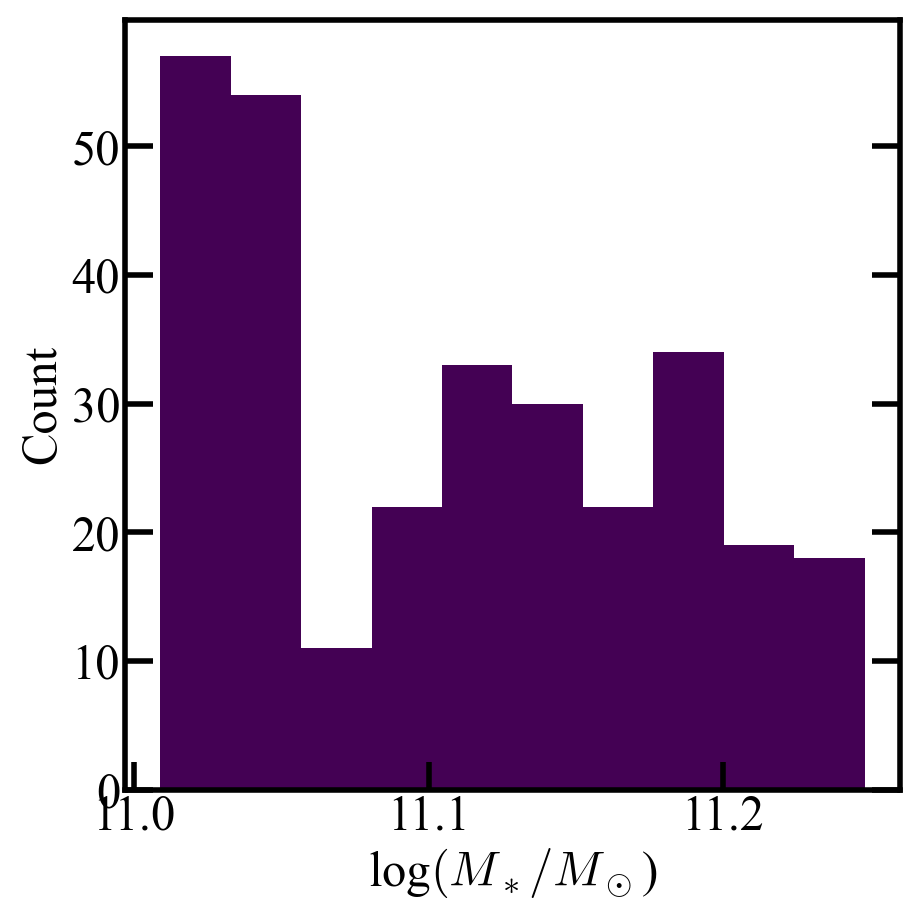

In [6]:
#------------GALAXY STELLAR MASS DISTRIBTUION--------------------#
plt.hist(np.log10(stell)[indices])
plt.ylabel('Count')
plt.xlabel('log$(M_*/M_\odot$)')

/var/folders/kp/32s7fb1928zctcd3kqpfcz9c0000gn/T/ipykernel_51184/2478992262.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.hist(np.log10(halo)[indices])


Text(0.5, 0, 'log$(M_h/M_\\odot$)')

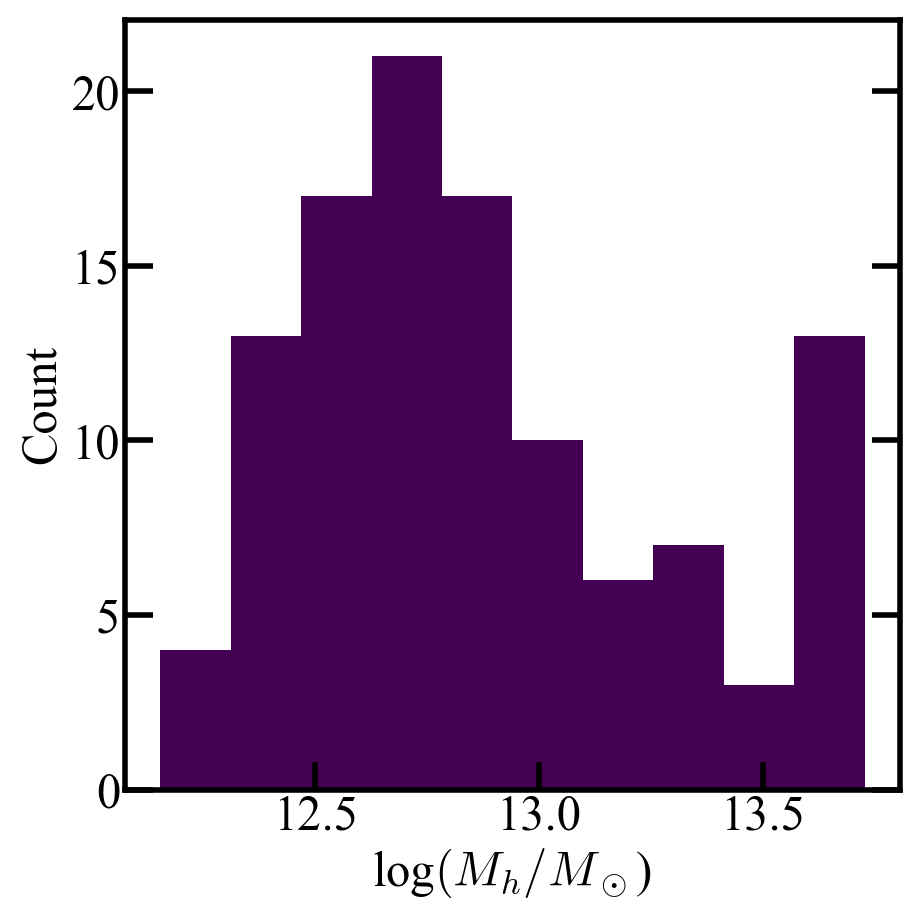

In [23]:
#------------GALAXY HALO MASS DISTRIBTUION--------------------#
plt.hist(np.log10(halo)[indices])
plt.ylabel('Count')
plt.xlabel('log$(M_h/M_\odot$)')

In [33]:
#-----------------Xray Sample Matching-----------------------#
data_file = '../testing/RAFIKI_E_z01_highranges_dissertation_szdat.hdf5'  #path to saved stacked radial data-should be the only thing you need to change

In [34]:
with h5py.File(data_file, 'r') as f:
    sim_name = f['metadata'].attrs['simulation']
    redshift = f['metadata'].attrs['redshift']
    indices = f['metadata'].attrs['galaxy_indices'][:]

In [35]:
len(indices)

39

In [80]:
path_to_package_data = '/Volumes/easystore/RAFIKI_CGM_mock_library/'

red_shift = {'0.1':'0_1', '0.5':'0_5', '1':'1', '1.0':'1','2':'2','2.0':'2','1.':'1','2.':'2'} #To account for possible names
if redshift not in red_shift:
    raise ValueError(f"Redshift '{redshift}' not recognized. Valid options are: 0.1, 0.5, 1, 2")

path = path_to_package_data+sim_name+'/snap_z'+red_shift[redshift]+'/galaxy_catalog.hdf5'
with h5py.File(path, 'r') as f:

    stell = f['galaxy_properties/stellar_mass'][:]
    dm_mass      = f['galaxy_properties/dm_mass'][:]
    m200c        = f['galaxy_properties/m200c'][:]
    r200c        = f['galaxy_properties/r200c'][:]
    halo       = f['galaxy_properties/m500c'][:]
    rad        = f['galaxy_properties/r500c'][:]
    age          = f['galaxy_properties/age'][:]
    sfr          = f['galaxy_properties/sfr'][:]
    central = f['galaxy_properties/central'][:]

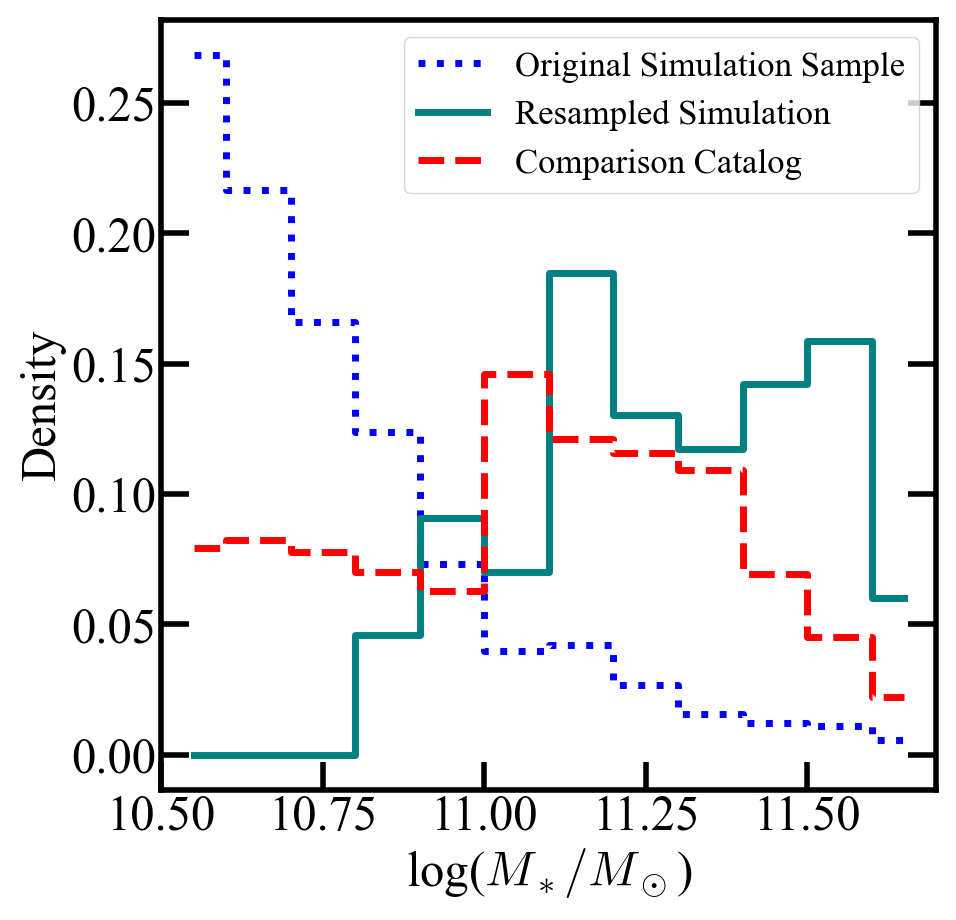

In [81]:
#------------GALAXY STELLAR MASS DISTRIBTUION--------------------#

#Loading observation histogram
obs_catalog = '../keep_CEN.csv'
obs_data    = np.array(pd.read_csv(obs_catalog, header=None))
bins = [10.5, 10.6,10.7,  10.8, 10.9, 11, 11.1,11.2,  11.3, 11.4, 11.5, 11.6, 11.7]
obs_hist,bin_edges = np.histogram(obs_data,bins=bins)
obs_hist_norm =obs_hist/np.sum(obs_hist)

resampled_data = np.log10(stell)[indices]
orig_hist,b = np.histogram(np.log10(stell), bins=bins)
orig_hist_norm = orig_hist/np.sum(orig_hist)
res_hist,b = np.histogram(resampled_data, bins=bins)
res_hist_norm = res_hist/np.sum(res_hist)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.step(bin_centers, orig_hist_norm, where='mid',
         color='blue', linestyle=':', linewidth=5, label='Original Simulation Sample')

plt.step(bin_centers, res_hist_norm, where='mid',
         color='teal', linestyle='-', linewidth=5,label='Resampled Simulation')

plt.step(bin_centers, obs_hist_norm, where='mid',
         color='red', linestyle='--', linewidth=5, label='Comparison Catalog')
plt.legend(fontsize=25)
plt.xlim(10.5,11.7)
plt.xlabel('log($M_*/M_\odot$)')
plt.ylabel('Density')
#plt.savefig('resampling_n400.png')
plt.show()




/var/folders/kp/32s7fb1928zctcd3kqpfcz9c0000gn/T/ipykernel_51184/212016293.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.hist(np.log10(halo)[indices])


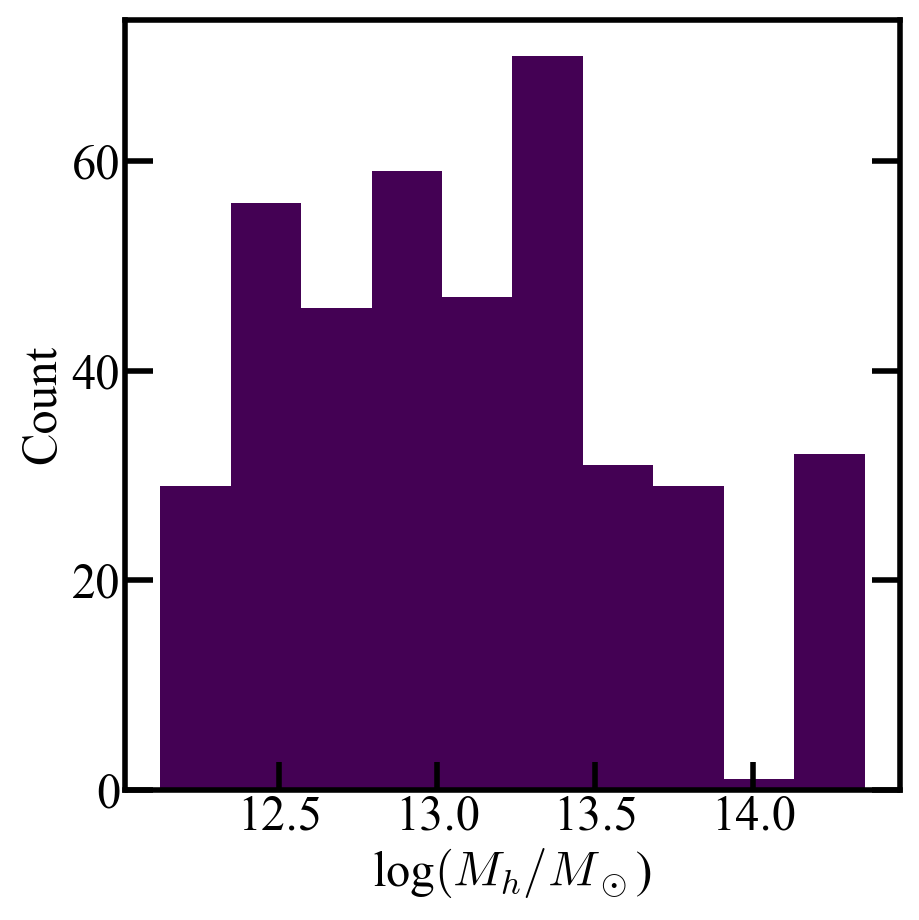

In [77]:
#------------GALAXY HALO MASS DISTRIBTUION--------------------#
plt.hist(np.log10(halo)[indices])
#a = list(set(indices))
#plt.hist(np.log10(halo)[a])
plt.ylabel('Count')
plt.xlabel('log$(M_h/M_\odot$)')
plt.savefig('halodistribution.png')